# **Notebook:** `01_pre_eda_and_cleaning.ipynb`

**Mục tiêu:** Xây dựng đầy đủ pipeline tiền xử lý dữ liệu nhu cầu tiêu thụ điện năng của lưới điện Great Britain (NESO Historic Demand Data), giai đoạn từ năm 2020 đến năm 2025 (6 năm dữ liệu đầy đủ):

1. **Mô tả bộ dữ liệu (Dataset Description)**: xác định đúng phạm vi địa lý và đơn vị vận hành chịu trách nhiệm công bố dữ liệu.
2. **Nhận dữ liệu thô (Raw Data Ingestion)**: đọc và hợp nhất đồng thời 6 tệp dữ liệu gốc.
3. **Khảo sát sơ bộ (Pre EDA)**: kiểm tra chất lượng dữ liệu bề nổi, phát hiện các ngày lệch nhịp do đổi giờ DST, quét giá trị bất thường vật lý.
4. **Sửa lỗi hệ thống (Cleaning)**: đồng bộ hóa trục thời gian, loại bỏ cột không nhất quán, nội suy tuyến tính lấp đầy các ô trống và điểm dị thường.
5. **Xuất dữ liệu sạch (Export)**: nghiệm thu an toàn và lưu kết quả thành tệp `electricity_cleaned.csv`.

**Nguồn dữ liệu (6 tệp gốc):**
1. `demanddata_2020.csv`
2. `demanddata_2021.csv`
3. `demanddata_2022.csv`
4. `demanddata_2023.csv`
5. `demanddata_2024.csv`
6. `demanddata_2025.csv`


## Mô tả bộ dữ liệu (Dataset Description)

Bộ dữ liệu sử dụng trong notebook này là **Historic Demand Data**, do **NESO (National Energy System Operator)** công bố công khai.

**Phạm vi địa lý Great Britain (GB), không phải toàn bộ United Kingdom (UK):** dữ liệu nhu cầu điện trong các tệp `demanddata_*.csv` bao trùm ba vùng hợp thành Great Britain, gồm England, Wales và Scotland. Bộ dữ liệu **không bao gồm Northern Ireland**, vì lưới điện Northern Ireland vận hành tách biệt trong **Single Electricity Market (SEM)** cùng với Cộng hòa Ireland, dưới sự quản lý của một cơ quan điều tiết khác (Utility Regulator / SEMO), chứ không thuộc phạm vi vận hành của NESO. Vì vậy, mọi kết luận rút ra từ notebook này (và các notebook sau) chỉ có giá trị đại diện cho **GB**, và cần tránh diễn đạt khái quát hoá thành "Vương quốc Anh" hay "UK" trong các phần trình bày tiếp theo của đề tài.

**Đơn vị chịu trách nhiệm NESO:** NESO là đơn vị vận hành hệ thống quốc gia (national system operator), chịu trách nhiệm cân bằng cung - cầu điện theo thời gian thực và hoạch định chiến lược cho hệ thống truyền tải điện và khí đốt trên toàn bộ Great Britain. NESO chính thức đi vào hoạt động từ ngày 1 tháng 10 năm 2024, sau khi Chính phủ Anh mua lại và chuyển đơn vị tiền thân  **National Grid Electricity System Operator (National Grid ESO)**  từ sở hữu tư nhân (thuộc tập đoàn National Grid) sang sở hữu công, theo Energy Act 2023. Do đó, các tệp dữ liệu gốc từ giai đoạn 2020 đến trước tháng 10 năm 2024 được công bố dưới tên "National Grid ESO", còn dữ liệu công bố từ sau mốc này mang tên "NESO"; đây là cùng một đơn vị vận hành, chỉ khác tên gọi và hình thức sở hữu, nên không ảnh hưởng đến tính liên tục hay độ tin cậy của chuỗi thời gian được ghép nối trong notebook này.


### Nhập thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (14, 5)

import os

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)


def save_figure(fig, name):
    """Lưu hình ở định dạng PDF vector (phù hợp cho đồ thị dạng đường/trục liên tục, tránh vỡ nét khi in ấn hoặc thu nhỏ trong LaTeX)."""
    path = os.path.join(FIGURES_DIR, f"{name}.pdf")
    fig.savefig(path, format="pdf", dpi=600, bbox_inches="tight")
    print(f"Đã lưu hình: {path}")


print("Đã nhập xong các thư viện cần thiết.")


Đã nhập xong các thư viện cần thiết.


## Part 1: Nhận dữ liệu thô (Raw Data Ingestion)
1. Đọc lần lượt từng tệp csv (2020 đến 2025) vào DataFrame riêng biệt, gắn nhãn năm nguồn để truy vết về sau.
2. Kiểm tra cấu trúc danh sách cột (Schema Matching) giữa các năm trước khi gộp, để biết trước cột nào sẽ phát sinh giá trị khuyết.
3. Gộp dữ liệu theo chiều dọc (Vertical Concatenation) thành một DataFrame duy nhất.


In [2]:
FILE_PATHS = {
    2020: "demanddata_2020.csv",
    2021: "demanddata_2021.csv",
    2022: "demanddata_2022.csv",
    2023: "demanddata_2023.csv",
    2024: "demanddata_2024.csv",
    2025: "demanddata_2025.csv",
}

raw_frames = {}
for year, path in FILE_PATHS.items():
    df_year = pd.read_csv(path)
    df_year["SOURCE_FILE_YEAR"] = year
    raw_frames[year] = df_year
    print(f"Năm {year}: đọc được {df_year.shape[0]:,} dòng, {df_year.shape[1]} cột")


Năm 2020: đọc được 17,568 dòng, 22 cột
Năm 2021: đọc được 17,520 dòng, 22 cột
Năm 2022: đọc được 17,520 dòng, 22 cột
Năm 2023: đọc được 17,520 dòng, 23 cột
Năm 2024: đọc được 17,568 dòng, 23 cột
Năm 2025: đọc được 17,520 dòng, 23 cột


In [3]:
column_sets = {year: set(df.columns).difference({"SOURCE_FILE_YEAR"}) for year, df in raw_frames.items()}

nam_goc = 2025
cot_goc = column_sets[nam_goc]

print(f"Đối chiếu danh sách cột so với tệp năm gốc ({nam_goc}):\n")
for year, cols in column_sets.items():
    cot_thua = cols.difference(cot_goc)      # cột chỉ có ở năm này, không có ở năm gốc
    cot_thieu = cot_goc.difference(cols)     # cột có ở năm gốc nhưng không có ở năm này
    print(f"Năm {year}: thừa {sorted(cot_thua) if cot_thua else 'không có'}, "
          f"thiếu {sorted(cot_thieu) if cot_thieu else 'không có'}")


Đối chiếu danh sách cột so với tệp năm gốc (2025):

Năm 2020: thừa không có, thiếu ['SCOTTISH_TRANSFER']
Năm 2021: thừa không có, thiếu ['SCOTTISH_TRANSFER']
Năm 2022: thừa không có, thiếu ['SCOTTISH_TRANSFER']
Năm 2023: thừa không có, thiếu không có
Năm 2024: thừa không có, thiếu không có
Năm 2025: thừa không có, thiếu không có


**Nhận xét sơ bộ:** ba tệp `demanddata_2020.csv`, `demanddata_2021.csv` và `demanddata_2022.csv` thiếu cột `SCOTTISH_TRANSFER` so với các tệp từ năm 2023 trở đi. Đây là cột ghi nhận lượng công suất trao đổi qua biên giới Scotland, chỉ được đơn vị vận hành hệ thống (National Grid ESO, nay là NESO xem mục Mô tả bộ dữ liệu ở đầu notebook) bổ sung vào cấu trúc tệp công bố kể từ năm 2023. Do đó, sau khi gộp dữ liệu, cột này sẽ phát sinh giá trị khuyết (NaN) cho toàn bộ các dòng thuộc giai đoạn 2020 đến 2022. Đây chính là một trong những "lỗi hệ thống" mà Cleaning (Part 3) sẽ xử lý triệt để bằng cách loại bỏ hoàn toàn cột này.

In [4]:
df_raw = pd.concat(
    [raw_frames[y] for y in sorted(raw_frames)],
    axis=0,
    ignore_index=True,
    sort=False,
)

print(f"Kích thước dữ liệu sau khi hợp nhất: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột")
df_raw.head()


Kích thước dữ liệu sau khi hợp nhất: 105,216 dòng, 23 cột


,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SOURCE_FILE_YEAR,SCOTTISH_TRANSFER
0,01-JAN-2020,1,26340,27153,23821,1073,6465,0,13040,0,15,1703,0,852,-151,-47,854,0,0,0,0,2020,NaN
1,01-JAN-2020,2,26921,27684,24393,1020,6465,0,13040,0,17,1703,0,853,-146,0,854,0,0,0,0,2020,NaN
2,01-JAN-2020,3,26569,27240,24085,1010,6465,0,13040,0,18,1703,0,852,-53,0,854,0,0,0,0,2020,NaN
3,01-JAN-2020,4,25754,26435,23350,1043,6465,0,13040,0,15,1703,0,852,-66,0,854,0,0,0,0,2020,NaN
4,01-JAN-2020,5,25075,25824,22788,1001,6465,0,13040,0,15,1704,0,853,-74,-60,854,0,0,0,0,2020,NaN


In [5]:
df_raw["SOURCE_FILE_YEAR"].value_counts().sort_index()


,count
SOURCE_FILE_YEAR,
2020,17568
2021,17520
2022,17520
2023,17520
2024,17568
2025,17520


## Part 2: Khảo sát sơ bộ (Pre EDA)

Mục tiêu của phần này là khảo sát, chưa can thiệp sửa chữa.
1. Kích thước, kiểu dữ liệu.
2. Kiểm tra giá trị khuyết (NaN).
3. Thống kê mô tả và trực quan hóa phân phối các thuộc tính định lượng.
4. Quét các giá trị bất thường vật lý (nhu cầu điện nhỏ hơn hoặc bằng không).
5. Khảo sát trục thời gian: phát hiện các ngày lệch nhịp chu kỳ do hiệu ứng đổi giờ DST.

Kết quả của Part 2 sẽ là danh sách các vấn đề cần được xử lý ở Part 3.


### 2.1. Kích thước và kiểu dữ liệu

In [6]:
so_dong, so_cot = df_raw.shape
dung_luong_mb = df_raw.memory_usage(deep=True).sum() / (1024 ** 2)

print("=== KÍCH THƯỚC DỮ LIỆU ===")
print(f"Số dòng (observations)   : {so_dong:,}")
print(f"Số cột (attributes)      : {so_cot}")
print(f"Dung lượng bộ nhớ (RAM)  : {dung_luong_mb:.2f} MB")
print(f"Giai đoạn thời gian      : từ năm 2020 đến năm 2025 (6 năm)")
print(f"Số tệp nguồn hợp nhất    : {df_raw['SOURCE_FILE_YEAR'].nunique()} tệp")


=== KÍCH THƯỚC DỮ LIỆU ===
Số dòng (observations)   : 105,216
Số cột (attributes)      : 23
Dung lượng bộ nhớ (RAM)  : 23.63 MB
Giai đoạn thời gian      : từ năm 2020 đến năm 2025 (6 năm)
Số tệp nguồn hợp nhất    : 6 tệp


In [7]:
print("=== KIỂU DỮ LIỆU THEO TỪNG CỘT ===\n")
print(df_raw.dtypes)


=== KIỂU DỮ LIỆU THEO TỪNG CỘT ===

SETTLEMENT_DATE               object
SETTLEMENT_PERIOD              int64
ND                             int64
TSD                            int64
ENGLAND_WALES_DEMAND           int64
EMBEDDED_WIND_GENERATION       int64
EMBEDDED_WIND_CAPACITY         int64
EMBEDDED_SOLAR_GENERATION      int64
EMBEDDED_SOLAR_CAPACITY        int64
NON_BM_STOR                    int64
PUMP_STORAGE_PUMPING           int64
IFA_FLOW                       int64
IFA2_FLOW                      int64
BRITNED_FLOW                   int64
MOYLE_FLOW                     int64
EAST_WEST_FLOW                 int64
NEMO_FLOW                      int64
NSL_FLOW                       int64
ELECLINK_FLOW                  int64
VIKING_FLOW                    int64
GREENLINK_FLOW                 int64
SOURCE_FILE_YEAR               int64
SCOTTISH_TRANSFER            float64
dtype: object


### 2.2. Kiểm tra giá trị khuyết (Check NA)

In [8]:
missing_report = pd.DataFrame({
    "số dòng khuyết": df_raw.isna().sum(),
    "tỷ lệ phần trăm khuyết (%)": (df_raw.isna().mean() * 100).round(4),
})
missing_report = missing_report.sort_values("số dòng khuyết", ascending=False)

print("=== BÁO CÁO GIÁ TRỊ KHUYẾT TRÊN TOÀN BỘ CỘT ===\n")
print(missing_report[missing_report["số dòng khuyết"] > 0])


=== BÁO CÁO GIÁ TRỊ KHUYẾT TRÊN TOÀN BỘ CỘT ===

                   số dòng khuyết  tỷ lệ phần trăm khuyết (%)
SCOTTISH_TRANSFER           52608                        50.0


**Nhận xét sơ bộ:** chỉ duy nhất cột `SCOTTISH_TRANSFER` xuất hiện giá trị khuyết, với 52.608 dòng (tương ứng chính xác tổng số dòng của 3 tệp 2020, 2021, 2022). Đây là giá trị khuyết mang tính **cấu trúc** (structural missingness), phát sinh do cột này chưa tồn tại trong dữ liệu công bố ở giai đoạn 2020 đến 2022, chứ không phải do lỗi đo đạc hay lỗi thu thập dữ liệu. Vì đây là lỗi cấu trúc chứ không phải lỗi ngẫu nhiên, hướng xử lý hợp lý nhất sẽ là loại bỏ hẳn cột này (thay vì nội suy hay điền giả định), và việc đó sẽ được thực hiện tường minh ở Part 3.

### 2.3. Descriptive Statistical (Thống kê mô tả)

In [9]:
cot_dinh_luong = df_raw.select_dtypes(include=[np.number]).columns.tolist()

thong_ke_mo_ta = df_raw[cot_dinh_luong].describe().T
thong_ke_mo_ta["skewness"] = df_raw[cot_dinh_luong].skew()
thong_ke_mo_ta["kurtosis"] = df_raw[cot_dinh_luong].kurt()

print("=== THỐNG KÊ MÔ TẢ TRÊN CÁC THUỘC TÍNH ĐỊNH LƯỢNG ===\n")
thong_ke_mo_ta.round(2)

=== THỐNG KÊ MÔ TẢ TRÊN CÁC THUỘC TÍNH ĐỊNH LƯỢNG ===



,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
SETTLEMENT_PERIOD,105216.0,24.50,13.85,1.0,12.75,24.5,36.25,50.0,0.00,-1.20
ND,105216.0,26770.07,6218.03,12803.0,21898.00,25883.5,30709.25,46433.0,0.55,-0.36
TSD,105216.0,28737.56,5933.03,15297.0,24228.00,27808.5,32383.00,47760.0,0.60,-0.26
ENGLAND_WALES_DEMAND,105216.0,24532.27,5692.56,12040.0,20065.00,23682.5,28164.00,42458.0,0.56,-0.38
EMBEDDED_WIND_GENERATION,105216.0,1887.20,1213.00,125.0,912.00,1557.0,2625.00,5962.0,0.90,0.05
EMBEDDED_WIND_CAPACITY,105216.0,6549.76,38.64,6465.0,6527.00,6545.0,6562.00,6622.0,0.26,-0.32
EMBEDDED_SOLAR_GENERATION,105216.0,1579.14,2484.69,0.0,0.00,5.0,2527.00,14046.0,1.72,2.40
EMBEDDED_SOLAR_CAPACITY,105216.0,15980.56,2684.91,13040.0,13725.00,15037.0,17815.00,22126.0,0.80,-0.58
NON_BM_STOR,105216.0,0.42,9.97,0.0,0.00,0.0,0.00,481.0,30.31,1055.08
PUMP_STORAGE_PUMPING,105216.0,192.77,362.33,0.0,7.00,11.0,158.00,1869.0,2.02,3.11


### 2.4. Numerical Attributes (Thuộc tính định lượng)

Sau bước Change Types, các thuộc tính định lượng (numerical) của bộ dữ liệu bao gồm các cột đo lường công suất/nhu cầu điện dạng liên tục (MW), cụ thể: `ND`, `TSD`, `ENGLAND_WALES_DEMAND`, các cột phát điện/công suất phân tán (`EMBEDDED_WIND_GENERATION`, `EMBEDDED_WIND_CAPACITY`, `EMBEDDED_SOLAR_GENERATION`, `EMBEDDED_SOLAR_CAPACITY`), cùng các cột dòng công suất trao đổi liên kết (`*_FLOW`, `SCOTTISH_TRANSFER`, `NON_BM_STOR`, `PUMP_STORAGE_PUMPING`).

In [10]:
print(f"Tổng số thuộc tính định lượng: {len(cot_dinh_luong)}\n")
for c in cot_dinh_luong:
    print(f" - {c}")

Tổng số thuộc tính định lượng: 22

 - SETTLEMENT_PERIOD
 - ND
 - TSD
 - ENGLAND_WALES_DEMAND
 - EMBEDDED_WIND_GENERATION
 - EMBEDDED_WIND_CAPACITY
 - EMBEDDED_SOLAR_GENERATION
 - EMBEDDED_SOLAR_CAPACITY
 - NON_BM_STOR
 - PUMP_STORAGE_PUMPING
 - IFA_FLOW
 - IFA2_FLOW
 - BRITNED_FLOW
 - MOYLE_FLOW
 - EAST_WEST_FLOW
 - NEMO_FLOW
 - NSL_FLOW
 - ELECLINK_FLOW
 - VIKING_FLOW
 - GREENLINK_FLOW
 - SOURCE_FILE_YEAR
 - SCOTTISH_TRANSFER


Đã lưu hình: figures/eda_demand_distribution.pdf


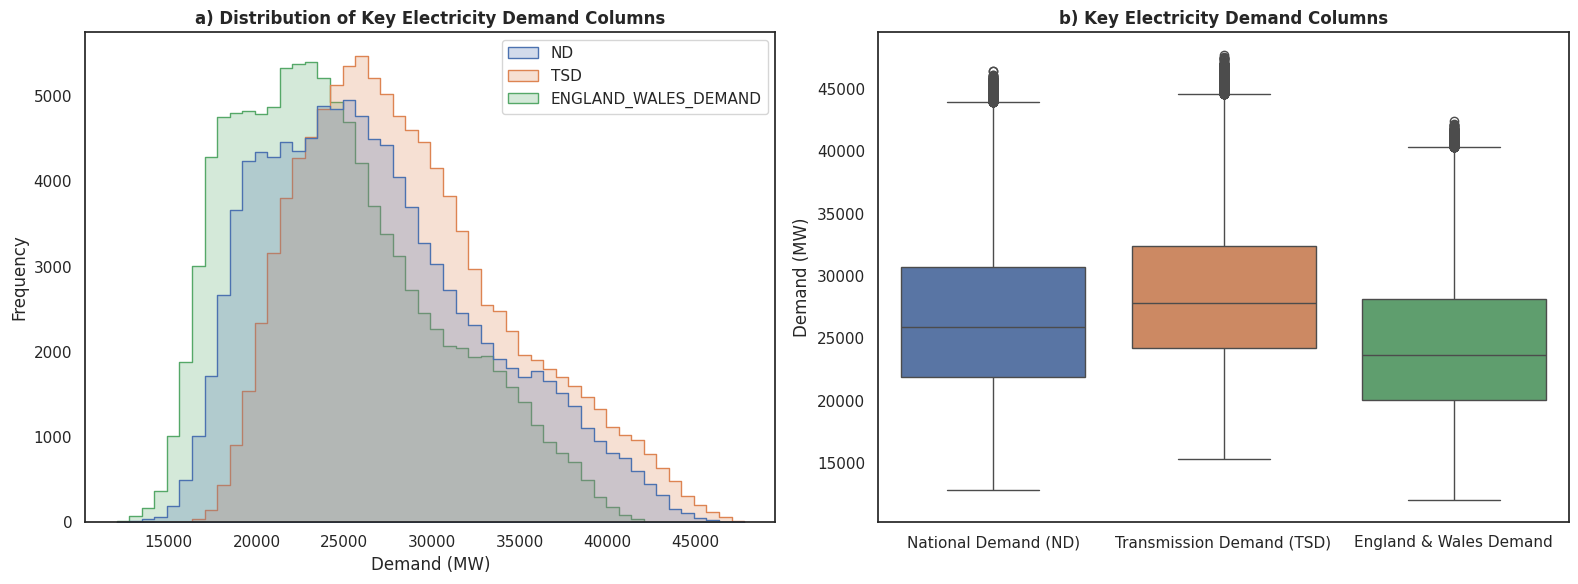

In [11]:
# Visualizing Distribution of Core Quantitative Attributes (Electricity Demand)
plt.close('all')

cot_nhu_cau = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#ĐỒ THỊ 1 (BÊN TRÁI): HISTOGRAM GỘP
sns.histplot(data=df_raw[cot_nhu_cau], bins=50, ax=axes[0], kde=False, element="step")
axes[0].set_title("a) Distribution of Key Electricity Demand Columns", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Demand (MW)")
axes[0].set_ylabel("Frequency")

#ĐỒ THỊ 2 (BÊN PHẢI): BOXPLOT
sns.boxplot(data=df_raw[cot_nhu_cau], ax=axes[1], legend=False)
axes[1].set_title("b) Key Electricity Demand Columns", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Demand (MW)")

new_labels = ["National Demand (ND)", "Transmission Demand (TSD)", "England & Wales Demand"]
axes[1].set_xticks(range(len(new_labels)))
axes[1].set_xticklabels(new_labels)

#  Xuất đồ thị độc lập
plt.tight_layout()
save_figure(fig, "eda_demand_distribution")
plt.show()

Đã lưu hình: figures/eda_renewable_distribution.pdf


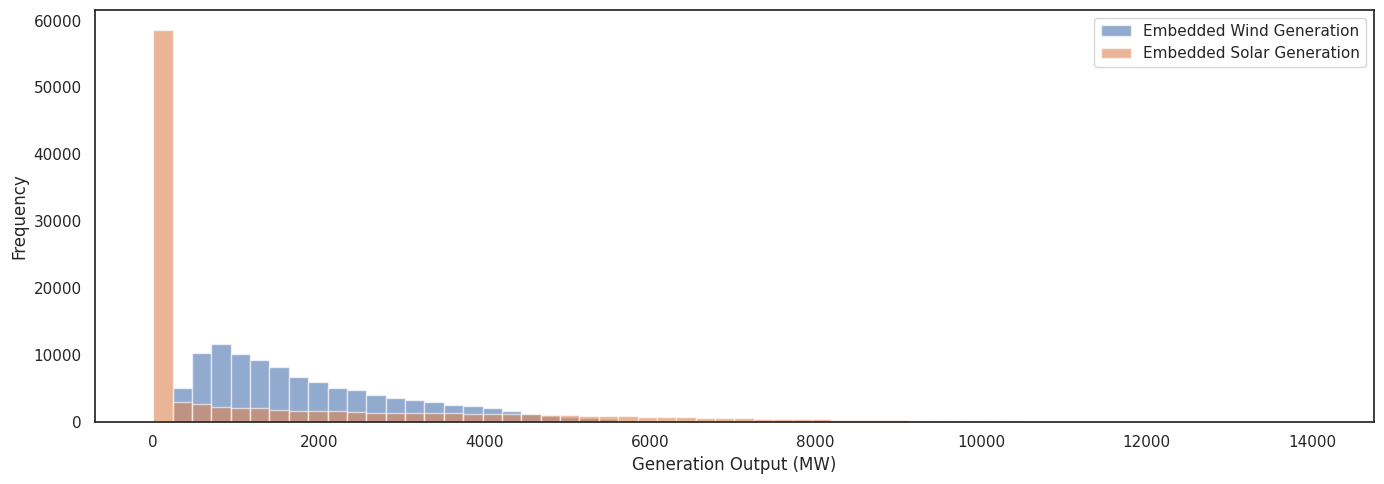

In [12]:
#  Visualizing Distribution of Distributed Renewable Energy Attributes
cot_tai_tao = ["EMBEDDED_WIND_GENERATION", "EMBEDDED_SOLAR_GENERATION"]

fig, ax = plt.subplots(figsize=(14, 5))
df_raw[cot_tai_tao].plot(kind="hist", bins=60, alpha=0.6, ax=ax)

# title: Distribution of Embedded Wind and Solar Generation Capacity
ax.set_xlabel("Generation Output (MW)")
ax.set_ylabel("Frequency")
ax.legend(["Embedded Wind Generation", "Embedded Solar Generation"], loc="upper right")

plt.tight_layout()
save_figure(fig, "eda_renewable_distribution")
plt.show()

### 2.5. Quét giá trị bất thường vật lý (Sanity Check)

Kiểm tra tính hợp lý về mặt vật lý hệ thống điện: tìm các giá trị nhu cầu điện âm hoặc bằng không, vốn là dấu hiệu bất thường vì nhu cầu điện tiêu thụ thực tế không bao giờ chạm mức không trên một lưới điện quốc gia đang vận hành.

In [13]:
demand_columns = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]

print("=== QUÉT GIÁ TRỊ BẤT THƯỜNG VẬT LÝ (nhỏ hơn hoặc bằng không) ===\n")
tong_diem_bat_thuong = 0
for col in demand_columns:
    so_dong_am = (df_raw[col] < 0).sum()
    so_dong_bang_khong = (df_raw[col] == 0).sum()
    tong_diem_bat_thuong += so_dong_am + so_dong_bang_khong
    print(f"Cột {col}:")
    print(f"   Số dòng có giá trị âm         : {so_dong_am}")
    print(f"   Số dòng có giá trị bằng không : {so_dong_bang_khong}")

print(f"\nTổng số điểm bất thường vật lý phát hiện: {tong_diem_bat_thuong}")


=== QUÉT GIÁ TRỊ BẤT THƯỜNG VẬT LÝ (nhỏ hơn hoặc bằng không) ===

Cột ND:
   Số dòng có giá trị âm         : 0
   Số dòng có giá trị bằng không : 0
Cột TSD:
   Số dòng có giá trị âm         : 0
   Số dòng có giá trị bằng không : 0
Cột ENGLAND_WALES_DEMAND:
   Số dòng có giá trị âm         : 0
   Số dòng có giá trị bằng không : 0

Tổng số điểm bất thường vật lý phát hiện: 0


**Nhận xét sơ bộ:** không phát hiện bất kỳ giá trị âm hoặc bằng không nào trên cả ba cột nhu cầu cốt lõi, do đây là dữ liệu đã qua quy trình quyết toán vận hành hệ thống điện của đơn vị vận hành lưới. Bước kiểm tra này vẫn bắt buộc phải thực hiện một cách tường minh để đảm bảo độ tin cậy, và hàm nội suy ở pha Cleaning sẽ vẫn được thiết kế tổng quát để tự động xử lý các điểm loại này nếu chúng xuất hiện trong tương lai.

### 2.6. Khảo sát trục thời gian: phát hiện lệch nhịp chu kỳ do DST

Lưới điện Great Britain (GB) chia mỗi ngày thành 48 chu kỳ quyết toán (Settlement Period), mỗi chu kỳ kéo dài đúng 30 phút, đánh số từ 1 đến 48. Riêng các ngày đổi giờ (Daylight Saving Time), số chu kỳ thực tế sẽ lệch khỏi con số chuẩn này:

* Ngày cuối tháng Ba (đổi giờ mùa xuân, đồng hồ nhảy tiến 1 giờ): mất đi 2 chu kỳ, chỉ còn **46 chu kỳ**.
* Ngày cuối tháng Mười (đổi giờ mùa thu, đồng hồ lùi lại 1 giờ): dư ra 2 chu kỳ, thành **50 chu kỳ**.

Trước khi đếm chu kỳ theo ngày, cần ép kiểu cột `SETTLEMENT_DATE` (hiện đang là chuỗi văn bản với định dạng không đồng nhất giữa các năm) sang kiểu ngày tháng chuẩn để phục vụ bước groupby bên dưới. Đây chỉ là bước chuẩn bị phục vụ chẩn đoán; việc chính thức hóa cột ngày tháng trong dữ liệu xuất ra sẽ được thực hiện lại ở pha Cleaning.


In [14]:
def parse_settlement_date(df):
    dinh_dang_theo_nam = {
        2020: "%d" + chr(45) + "%b" + chr(45) + "%Y",
        2021: "%d" + chr(45) + "%b" + chr(45) + "%Y",
        2022: "%d" + chr(45) + "%b" + chr(45) + "%Y",
        2023: "%d" + chr(45) + "%b" + chr(45) + "%y",
        2024: "%d" + chr(45) + "%b" + chr(45) + "%Y",
        2025: "%Y" + chr(45) + "%m" + chr(45) + "%d",
    }
    parsed_parts = []
    for year, group in df.groupby("SOURCE_FILE_YEAR"):
        fmt = dinh_dang_theo_nam[year]
        ngay_parsed = pd.to_datetime(group["SETTLEMENT_DATE"], format=fmt)
        parsed_parts.append(ngay_parsed)
    return pd.concat(parsed_parts).sort_index()


df_raw["SETTLEMENT_DATE_PARSED_TAM"] = parse_settlement_date(df_raw)
print("Đã ép kiểu tạm thời cột ngày tháng để phục vụ chẩn đoán DST.")
print(df_raw[["SETTLEMENT_DATE", "SOURCE_FILE_YEAR", "SETTLEMENT_DATE_PARSED_TAM"]].head(3))


Đã ép kiểu tạm thời cột ngày tháng để phục vụ chẩn đoán DST.
  SETTLEMENT_DATE  SOURCE_FILE_YEAR SETTLEMENT_DATE_PARSED_TAM
0     01-JAN-2020              2020                 2020-01-01
1     01-JAN-2020              2020                 2020-01-01
2     01-JAN-2020              2020                 2020-01-01


In [15]:
so_chu_ky_theo_ngay = df_raw.groupby("SETTLEMENT_DATE_PARSED_TAM")["SETTLEMENT_PERIOD"].count()

ngay_thieu_chu_ky = so_chu_ky_theo_ngay[so_chu_ky_theo_ngay < 48]
ngay_du_chu_ky = so_chu_ky_theo_ngay[so_chu_ky_theo_ngay > 48]

print(f"Tổng số ngày khảo sát: {so_chu_ky_theo_ngay.shape[0]:,}")
print(f"Số ngày lệch nhịp chu kỳ: {ngay_thieu_chu_ky.shape[0] + ngay_du_chu_ky.shape[0]}\n")

print("Các ngày THIẾU chu kỳ (đổi giờ mùa xuân, mất 2 chu kỳ):")
print(ngay_thieu_chu_ky)
print()
print("Các ngày DƯ chu kỳ (đổi giờ mùa thu, dư 2 chu kỳ):")
print(ngay_du_chu_ky)


Tổng số ngày khảo sát: 2,192
Số ngày lệch nhịp chu kỳ: 12

Các ngày THIẾU chu kỳ (đổi giờ mùa xuân, mất 2 chu kỳ):
SETTLEMENT_DATE_PARSED_TAM
2020-03-29    46
2021-03-28    46
2022-03-27    46
2023-03-26    46
2024-03-31    46
2025-03-30    46
Name: SETTLEMENT_PERIOD, dtype: int64

Các ngày DƯ chu kỳ (đổi giờ mùa thu, dư 2 chu kỳ):
SETTLEMENT_DATE_PARSED_TAM
2020-10-25    50
2021-10-31    50
2022-10-30    50
2023-10-29    50
2024-10-27    50
2025-10-26    50
Name: SETTLEMENT_PERIOD, dtype: int64


Đã lưu hình: figures/dst_anomaly_days.pdf


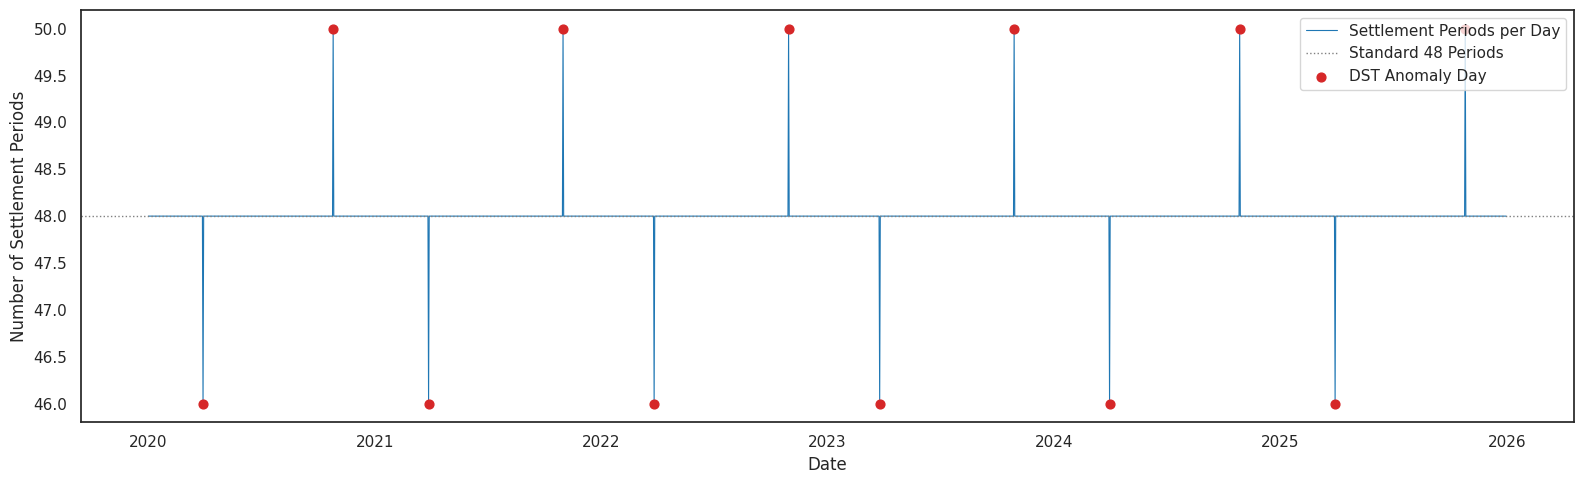

In [16]:
# Trực quan hóa số chu kỳ theo ngày, làm nổi bật các ngày lệch nhịp DST
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(so_chu_ky_theo_ngay.index, so_chu_ky_theo_ngay.values,
        color="tab:blue", linewidth=0.8, label="Settlement Periods per Day")
ax.axhline(48, color="gray", linestyle=":", linewidth=1, label="Standard 48 Periods")

ngay_bat_thuong = pd.concat([ngay_thieu_chu_ky, ngay_du_chu_ky])
ax.scatter(ngay_bat_thuong.index, ngay_bat_thuong.values,
           color="tab:red", s=40, zorder=5, label="DST Anomaly Day")

# title: Settlement Period Count per Day (2020 to 2025)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Settlement Periods")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
save_figure(fig, "dst_anomaly_days")
plt.show()


**Nhận xét tổng kết Pre EDA:** kết quả khảo sát xác định rõ danh sách việc cần làm ở pha Cleaning:

1. **Đồng bộ hóa trục thời gian**: 12 ngày lệch nhịp (6 ngày 46 chu kỳ, 6 ngày 50 chu kỳ, mỗi năm một cặp) cần được chuẩn hóa về đúng 48 chu kỳ.
2. **Loại bỏ cột không nhất quán**: `SCOTTISH_TRANSFER` mang giá trị khuyết cấu trúc, cần được loại bỏ.
3. **Nội suy các điểm trống/dị thường**: tuy hiện tại chưa phát hiện điểm nào, hàm xử lý vẫn được xây dựng tổng quát để đảm bảo an toàn.


## Part 3: Sửa lỗi hệ thống (Cleaning)

Tiến hành xử lý từng vấn đề đã khảo sát ở Part 2:
1. Đồng bộ hóa trục thời gian (đưa các ngày DST về đúng 48 chu kỳ chuẩn).
2. Loại bỏ cột không nhất quán `SCOTTISH_TRANSFER`.
3. Nội suy tuyến tính lấp đầy các ô trống `NaN` và các điểm dị thường vật lý.


### 3.1. Đồng bộ hóa trục thời gian (DST Resynchronization)

Phương pháp áp dụng: với mỗi ngày có số chu kỳ khác 48, ta **nội suy lại toàn bộ các cột số trên trục vị trí chuẩn hóa** (vị trí tương đối trong ngày, từ 0 đến 1) về đúng lưới 48 chu kỳ mục tiêu. Cách làm này xử lý được đồng thời cả hai trường hợp:

* Ngày 46 chu kỳ (thiếu): nội suy thêm (upsample) để bù lại 2 chu kỳ bị đồng hồ "nuốt mất".
* Ngày 50 chu kỳ (dư): nội suy gộp lại (downsample) 2 chu kỳ dư ra về đúng 48, vẫn giữ được hình dạng đường cong nhu cầu trong ngày (diurnal shape).

Ưu điểm của phương pháp này so với việc chỉ đơn giản xóa bớt hoặc lặp lại dòng: nó không làm mất thông tin về xu hướng tăng giảm của phụ tải trong ngày đổi giờ, điều rất quan trọng cho bước xây dựng đặc trưng (feature engineering) và huấn luyện mô hình dự báo về sau.


In [17]:
SO_CHU_KY_CHUAN = 48

cot_so_can_noi_suy = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cot_so_can_noi_suy = [c for c in cot_so_can_noi_suy if c not in ("SOURCE_FILE_YEAR",)]


def dong_bo_mot_ngay(nhom):
    so_chu_ky_hien_tai = len(nhom)
    nhom_sorted = nhom.sort_values("SETTLEMENT_PERIOD").reset_index(drop=True)

    if so_chu_ky_hien_tai == SO_CHU_KY_CHUAN:
        ket_qua = nhom_sorted[cot_so_can_noi_suy].copy()
        ket_qua["SETTLEMENT_PERIOD"] = range(1, SO_CHU_KY_CHUAN + 1)
        ket_qua["SETTLEMENT_DATE_PARSED_TAM"] = nhom_sorted["SETTLEMENT_DATE_PARSED_TAM"].iloc[0]
        ket_qua["SOURCE_FILE_YEAR"] = nhom_sorted["SOURCE_FILE_YEAR"].iloc[0]
        return ket_qua

    vi_tri_goc = np.linspace(0, 1, so_chu_ky_hien_tai)
    vi_tri_muc_tieu = np.linspace(0, 1, SO_CHU_KY_CHUAN)

    du_lieu_moi = {}
    for col in cot_so_can_noi_suy:
        if col == "SETTLEMENT_PERIOD":
            continue
        du_lieu_moi[col] = np.interp(vi_tri_muc_tieu, vi_tri_goc, nhom_sorted[col].values)

    ket_qua = pd.DataFrame(du_lieu_moi)
    ket_qua["SETTLEMENT_PERIOD"] = range(1, SO_CHU_KY_CHUAN + 1)
    ket_qua["SETTLEMENT_DATE_PARSED_TAM"] = nhom_sorted["SETTLEMENT_DATE_PARSED_TAM"].iloc[0]
    ket_qua["SOURCE_FILE_YEAR"] = nhom_sorted["SOURCE_FILE_YEAR"].iloc[0]
    return ket_qua


print(f"Tổng số ngày cần xử lý: {df_raw['SETTLEMENT_DATE_PARSED_TAM'].nunique():,}")
print(f"Trong đó số ngày cần đồng bộ hóa (khác {SO_CHU_KY_CHUAN} chu kỳ): "
      f"{(so_chu_ky_theo_ngay != SO_CHU_KY_CHUAN).sum()}")


Tổng số ngày cần xử lý: 2,192
Trong đó số ngày cần đồng bộ hóa (khác 48 chu kỳ): 12


In [18]:
danh_sach_ngay_dong_bo = []
for ngay, nhom in df_raw.groupby("SETTLEMENT_DATE_PARSED_TAM"):
    danh_sach_ngay_dong_bo.append(dong_bo_mot_ngay(nhom))

df_clean = pd.concat(danh_sach_ngay_dong_bo, ignore_index=True)
df_clean = df_clean.rename(columns={"SETTLEMENT_DATE_PARSED_TAM": "SETTLEMENT_DATE"})
df_clean = df_clean.sort_values(["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"]).reset_index(drop=True)

print(f"Kích thước dữ liệu sau khi đồng bộ hóa trục thời gian: "
      f"{df_clean.shape[0]:,} dòng, {df_clean.shape[1]} cột")


Kích thước dữ liệu sau khi đồng bộ hóa trục thời gian: 105,216 dòng, 23 cột


In [19]:
# Kiểm chứng: tất cả các ngày đều phải có đúng 48 chu kỳ sau khi đồng bộ hóa
kiem_chung_chu_ky = df_clean.groupby("SETTLEMENT_DATE")["SETTLEMENT_PERIOD"].count()
so_ngay_con_lech = (kiem_chung_chu_ky != SO_CHU_KY_CHUAN).sum()

print(f"Số ngày còn lệch nhịp sau khi đồng bộ hóa: {so_ngay_con_lech}")
assert so_ngay_con_lech == 0, "Vẫn còn ngày lệch nhịp sau bước đồng bộ hóa!"
print("Xác nhận: toàn bộ các ngày đều có đúng 48 chu kỳ quyết toán.")


Số ngày còn lệch nhịp sau khi đồng bộ hóa: 0
Xác nhận: toàn bộ các ngày đều có đúng 48 chu kỳ quyết toán.


Đã lưu hình: figures/dst_resync_example.pdf


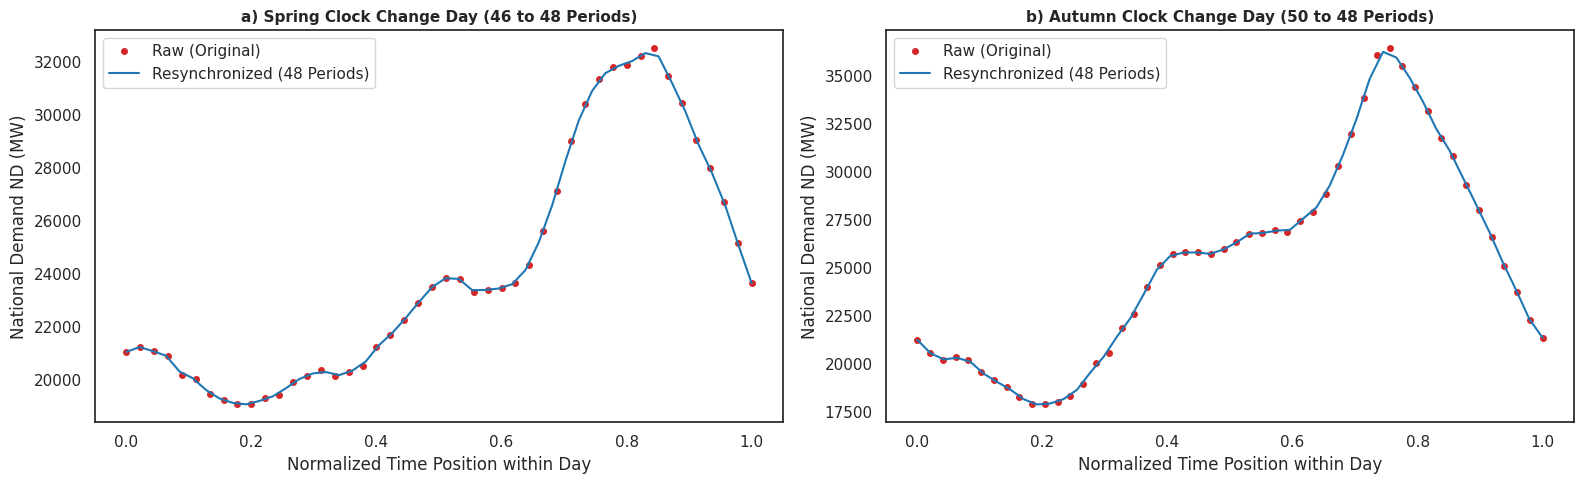

In [20]:
# Trực quan hóa minh họa: so sánh một ngày THIẾU chu kỳ và một ngày DƯ chu kỳ
# giữa dữ liệu thô (trước đồng bộ) và dữ liệu đã đồng bộ (sau xử lý)
ngay_vi_du_thieu = ngay_thieu_chu_ky.index[0]
ngay_vi_du_du = ngay_du_chu_ky.index[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, ngay_vi_du, tieu_de in zip(
    axes,
    [ngay_vi_du_thieu, ngay_vi_du_du],
    ["a) Spring Clock Change Day (46 to 48 Periods)", "b) Autumn Clock Change Day (50 to 48 Periods)"],
):
    goc = df_raw[df_raw["SETTLEMENT_DATE_PARSED_TAM"] == ngay_vi_du].sort_values("SETTLEMENT_PERIOD")
    sau = df_clean[df_clean["SETTLEMENT_DATE"] == ngay_vi_du].sort_values("SETTLEMENT_PERIOD")

    vi_tri_goc = np.linspace(0, 1, len(goc))
    vi_tri_sau = np.linspace(0, 1, len(sau))

    ax.plot(vi_tri_goc, goc["ND"].values, "o", color="tab:red", markersize=4, label="Raw (Original)")
    ax.plot(vi_tri_sau, sau["ND"].values, linestyle="solid", color="tab:blue", linewidth=1.5, label="Resynchronized (48 Periods)")
    ax.set_title(tieu_de, fontsize=11, fontweight="bold")
    ax.set_xlabel("Normalized Time Position within Day")
    ax.set_ylabel("National Demand ND (MW)")
    ax.legend()

plt.tight_layout()
save_figure(fig, "dst_resync_example")
plt.show()


### 3.2. Loại bỏ cột không nhất quán

`SCOTTISH_TRANSFER` chỉ tồn tại trong dữ liệu công bố kể từ năm 2023, gây ra 52.608 dòng giá trị khuyết mang tính cấu trúc ở giai đoạn 2020 đến 2022 (như đã chẩn đoán ở mục 2.2). Vì đây là khuyết cấu trúc (không thể nội suy hay ước lượng một cách đáng tin cậy cho cả một giai đoạn dài 3 năm), hướng xử lý minh bạch và an toàn nhất là loại bỏ hẳn cột này khỏi dữ liệu sạch.


In [21]:
if "SCOTTISH_TRANSFER" in df_clean.columns:
    df_clean = df_clean.drop(columns=["SCOTTISH_TRANSFER"])
    print("Đã loại bỏ cột SCOTTISH_TRANSFER khỏi dữ liệu sạch.")
else:
    print("Cột SCOTTISH_TRANSFER không tồn tại (có thể đã bị loại bỏ trước đó).")

print(f"Số cột còn lại: {df_clean.shape[1]}")
print(list(df_clean.columns))


Đã loại bỏ cột SCOTTISH_TRANSFER khỏi dữ liệu sạch.
Số cột còn lại: 22
['SETTLEMENT_PERIOD', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR', 'PUMP_STORAGE_PUMPING', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW', 'GREENLINK_FLOW', 'SETTLEMENT_DATE', 'SOURCE_FILE_YEAR']


### 3.3. Nội suy tuyến tính lấp đầy ô trống và điểm dị thường vật lý

Bước này gồm hai giai đoạn:

1. **Đánh dấu điểm cần xử lý**: các ô trống `NaN` còn sót lại, và các giá trị nhỏ hơn hoặc bằng không trên các cột nhu cầu điện (vì mang ý nghĩa vật lý không hợp lệ) đều được chuyển thành `NaN` để đưa vào cùng một quy trình xử lý.
2. **Nội suy tuyến tính** (`linear interpolation`) theo đúng thứ tự thời gian cho từng cột, giúp giá trị được điền vào mang tính liên tục, phù hợp với bản chất chuỗi thời gian, thay vì điền cứng bằng một hằng số cố định.


In [22]:
df_clean = df_clean.sort_values(["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"]).reset_index(drop=True)

so_o_trong_truoc = df_clean.isna().sum().sum()
print(f"Số ô trống NaN trước bước nội suy: {so_o_trong_truoc}")

# Đánh dấu các giá trị nhỏ hơn hoặc bằng không trên cột nhu cầu là điểm dị thường vật lý
for col in demand_columns:
    so_diem_di_thuong = (df_clean[col] <= 0).sum()
    if so_diem_di_thuong > 0:
        print(f"Phát hiện {so_diem_di_thuong} điểm dị thường vật lý trên cột {col}, đánh dấu thành NaN.")
        df_clean.loc[df_clean[col] <= 0, col] = np.nan

so_o_trong_sau_danh_dau = df_clean.isna().sum().sum()
print(f"Số ô trống cần nội suy (bao gồm cả NaN gốc và điểm dị thường vật lý): {so_o_trong_sau_danh_dau}")


Số ô trống NaN trước bước nội suy: 0
Số ô trống cần nội suy (bao gồm cả NaN gốc và điểm dị thường vật lý): 0


In [23]:
cot_can_noi_suy = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cot_can_noi_suy = [c for c in cot_can_noi_suy if c not in ("SETTLEMENT_PERIOD", "SOURCE_FILE_YEAR")]

for col in cot_can_noi_suy:
    df_clean[col] = df_clean[col].interpolate(method="linear", limit_direction="both")

so_o_trong_sau_noi_suy = df_clean.isna().sum().sum()
print(f"Số ô trống NaN sau bước nội suy tuyến tính: {so_o_trong_sau_noi_suy}")


Số ô trống NaN sau bước nội suy tuyến tính: 0


### 3.4. Trực quan hóa xác minh sau khi làm sạch

Phần này tạo ra hai đồ thị đường mang tính xác minh, được vẽ trên `df_clean`, tức dữ liệu đã đi qua bước đồng bộ hóa trục thời gian ở mục 3.1, nhằm kiểm chứng trực quan rằng cấu trúc thời gian và hình dạng đường cong nhu cầu vẫn hợp lý sau khi xử lý, đồng thời thấu hiểu các mô hình thời gian căn bản trong bộ dữ liệu:

1. **Biểu đồ phụ tải theo giờ (Phạm vi 1 tuần khảo sát):** Ghi lại các chu kỳ ngày đêm (diurnal cycles), làm nổi bật biến động giữa khung giờ cao điểm và thấp điểm qua các ngày liên tiếp.
2. **Xu hướng trung bình ngày trong dài hạn (2020 - 2025):** Ghi lại động lực học mang tính vĩ mô theo mùa, tiết lộ cách thời tiết và chu kỳ hàng năm thúc đẩy sự thay đổi nhu cầu trên toàn hệ thống.

*Ghi chú: cả hai đồ thị hiện đã tích hợp đồng thời Nhu cầu Quốc gia (ND), Nhu cầu Hệ thống Truyền tải (TSD) và Nhu cầu vùng England & Wales (ENGLAND_WALES_DEMAND).*


Đã lưu hình: figures/eda_intraday_demand_profile.pdf


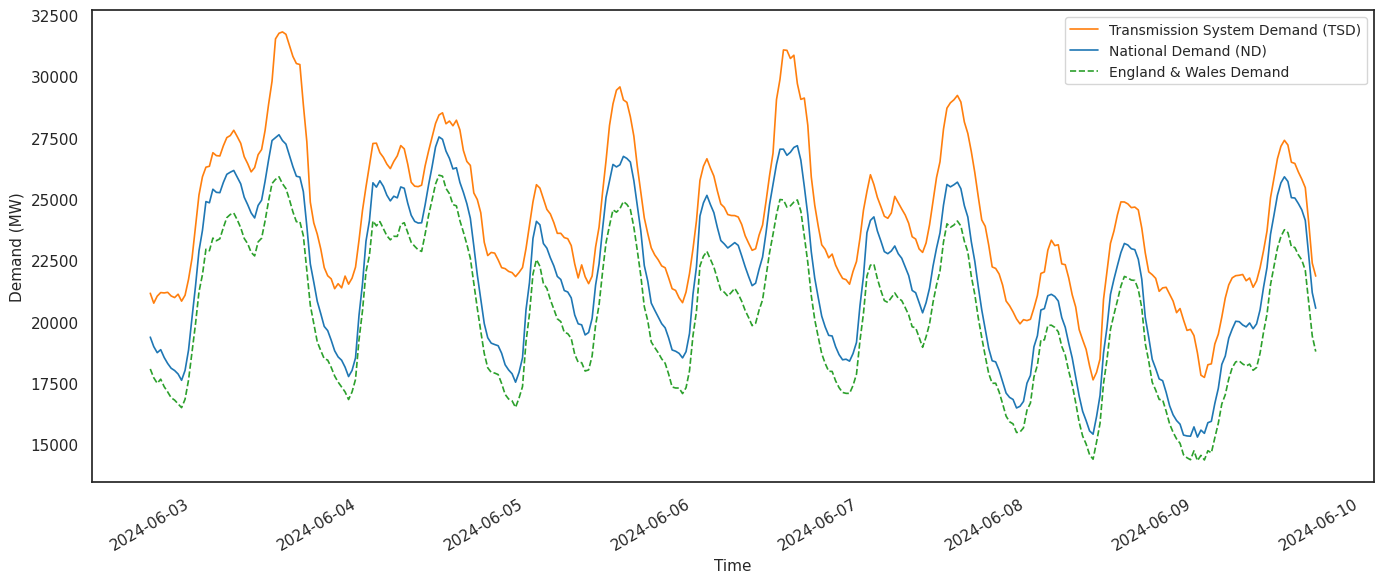

In [24]:
# Sắp xếp lại dữ liệu ĐÃ LÀM SẠCH theo trục thời gian
df_plot = df_clean.sort_values(["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"]).reset_index(drop=True)

# Tạo trục thời gian đầy đủ (datetime) bằng cách cộng thêm số phút tương ứng với chu kỳ quyết toán
df_plot["DATETIME_APPROX"] = df_plot["SETTLEMENT_DATE"] + pd.to_timedelta(
    (df_plot["SETTLEMENT_PERIOD"].astype(int) - 1) * 30, unit="m"
)

# --- PLOT 1: INTRADAY CYCLES (1-WEEK SURVEY) ---
# Lọc dữ liệu trong phạm vi 1 tuần khảo sát (03/06/2024 - 09/06/2024)
tuan_khao_sat = df_plot[
    (df_plot["DATETIME_APPROX"] >= "2024-06-03") & (df_plot["DATETIME_APPROX"] < "2024-06-10")
]


fig = plt.figure(figsize=(14, 6))

plt.plot(tuan_khao_sat["DATETIME_APPROX"], tuan_khao_sat["TSD"],
         color="tab:orange", linewidth=1.2, label="Transmission System Demand (TSD)")
plt.plot(tuan_khao_sat["DATETIME_APPROX"], tuan_khao_sat["ND"],
         color="tab:blue", linewidth=1.2, label="National Demand (ND)")
plt.plot(tuan_khao_sat["DATETIME_APPROX"], tuan_khao_sat["ENGLAND_WALES_DEMAND"],
         color="tab:green", linewidth=1.2, linestyle="--", label="England & Wales Demand")

# title: Hourly Electricity Demand Profile, Survey Week (03/06/2024 to 09/06/2024), Cleaned Data
plt.xlabel("Time", fontsize=11)
plt.ylabel("Demand (MW)", fontsize=11)
plt.xticks(rotation=30)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
save_figure(fig, "eda_intraday_demand_profile")
plt.show()

Đã lưu hình: figures/eda_daily_avg_demand_trend.pdf


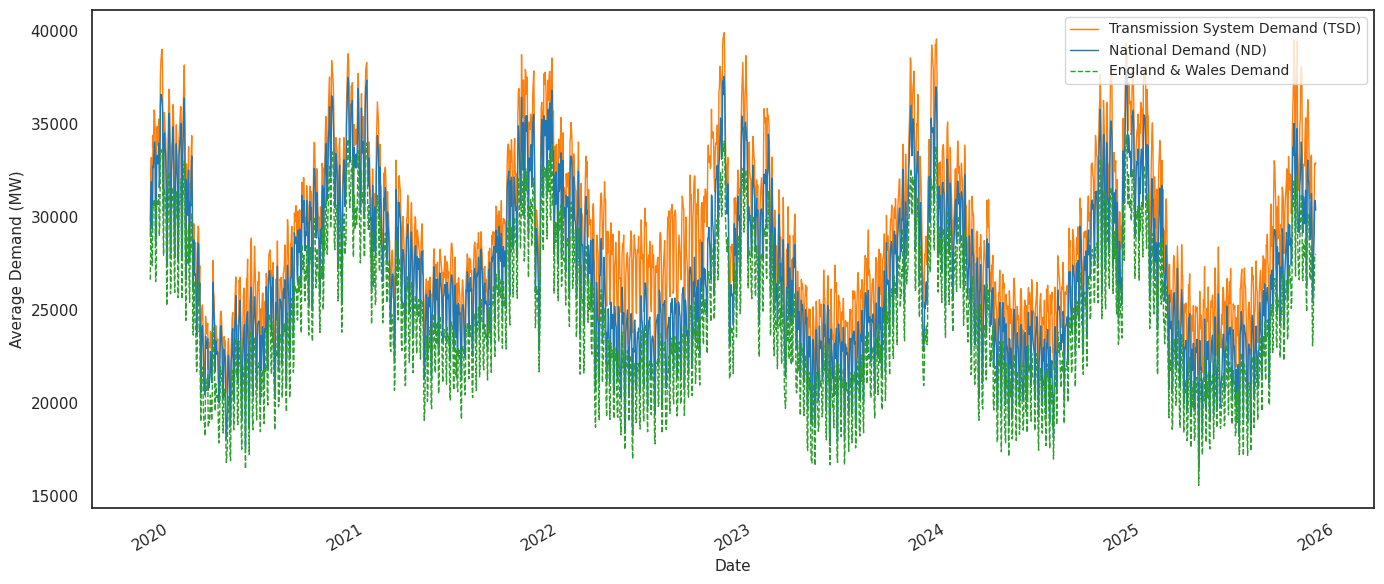

In [25]:
# --- PLOT 2: LONG-TERM SEASONAL TREND (DAILY AVERAGE) ---
# Đồ thị 2: nhu cầu điện gộp trung bình theo ngày trong toàn bộ giai đoạn 2020 đến 2025, trên dữ liệu đã làm sạch
nhu_cau_ngay = df_plot.groupby(df_plot["SETTLEMENT_DATE"].dt.date)[["TSD", "ND", "ENGLAND_WALES_DEMAND"]].mean()

fig = plt.figure(figsize=(14, 6))

plt.plot(nhu_cau_ngay.index, nhu_cau_ngay["TSD"],
         color="tab:orange", linewidth=1, label="Transmission System Demand (TSD)")
plt.plot(nhu_cau_ngay.index, nhu_cau_ngay["ND"],
         color="tab:blue", linewidth=1, label="National Demand (ND)")
plt.plot(nhu_cau_ngay.index, nhu_cau_ngay["ENGLAND_WALES_DEMAND"],
         color="tab:green", linewidth=1, linestyle="--", label="England & Wales Demand")

# Daily Average Electricity Demand Trend, Period 2020 to 2025, Cleaned Data
plt.xlabel("Date", fontsize=11)
plt.ylabel("Average Demand (MW)", fontsize=11)
plt.xticks(rotation=30)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
save_figure(fig, "eda_daily_avg_demand_trend")
plt.show()

**Nhận xét**:

Đồ thị theo tuần, tức chu kỳ ngắn hạn, thể hiện rõ tính chu kỳ ngày đêm đặc trưng với các đỉnh nhu cầu lặp lại ổn định vào các khung giờ cao điểm ban ngày và hạ sâu về đêm. Cả ba đường TSD, ND và England & Wales Demand di chuyển song song và đồng điệu với nhau, trong đó nhu cầu vùng England & Wales chiếm tỷ trọng áp đảo trong tổng nhu cầu quốc gia ND. Khoảng cách chênh lệch giữa TSD và ND phản ánh lượng điện tổn thất truyền tải, điện tự dùng của nhà máy và các hoạt động lưu trữ điện bằng thủy điện tích năng.

Đồ thị trung bình theo ngày, tức xu hướng dài hạn, thể hiện rõ tính mùa vụ sâu sắc của một quốc gia ôn đới như Great Britain, với tổng nhu cầu điện đạt đỉnh vào các tháng mùa đông và hạ thấp vào các tháng mùa hè, lặp lại đều đặn qua cả sáu năm quan sát từ 2020 đến 2025.

Vì cả hai đồ thị đều được vẽ trên df_clean và không cho thấy bất kỳ điểm gãy, đỉnh giả hay khoảng trống bất thường nào tại các ngày từng bị lệch nhịp do DST, kết quả này xác nhận bước đồng bộ hóa trục thời gian ở mục 3.1 đã bảo toàn đúng hình dạng đường cong nhu cầu trong ngày.


## Part 4: Xuất dữ liệu sạch (Export)

Trước khi lưu kết quả, ta chạy khối lệnh **nghiệm thu an toàn** (safety assertion), bao gồm hai điều kiện bắt buộc phải đạt:

1. Tỷ lệ ô trống `NaN` bằng 0% trên toàn bộ dữ liệu.
2. Tỷ lệ giá trị phụ tải âm hoặc bằng không bằng 0% trên các cột nhu cầu cốt lõi.

Chỉ khi cả hai điều kiện đều đạt, dữ liệu mới được phép lưu thành tệp `electricity_cleaned.csv`.


In [26]:
ty_le_o_trong = df_clean.isna().mean().mean() * 100

ty_le_am_hoac_khong = 0
for col in demand_columns:
    ty_le_am_hoac_khong += (df_clean[col] <= 0).sum()

print("=== NGHIỆM THU AN TOÀN ===\n")
print(f"Tỷ lệ ô trống NaN toàn bộ dữ liệu        : {ty_le_o_trong:.6f}%")
print(f"Số giá trị phụ tải âm hoặc bằng không    : {ty_le_am_hoac_khong}")
print(f"Tổng số dòng                             : {df_clean.shape[0]:,}")
print(f"Số dòng kỳ vọng (48 chu kỳ nhân tổng số ngày): {df_clean['SETTLEMENT_DATE'].nunique() * 48:,}")

assert df_clean.isna().sum().sum() == 0, "Vẫn còn ô trống NaN trong dữ liệu!"
assert ty_le_am_hoac_khong == 0, "Vẫn còn giá trị phụ tải không hợp lệ!"
assert df_clean.shape[0] == df_clean["SETTLEMENT_DATE"].nunique() * 48, "Sai lệch về số dòng so với kỳ vọng!"

print("\nXác nhận: dữ liệu đã vượt qua toàn bộ nghiệm thu an toàn.")


=== NGHIỆM THU AN TOÀN ===

Tỷ lệ ô trống NaN toàn bộ dữ liệu        : 0.000000%
Số giá trị phụ tải âm hoặc bằng không    : 0
Tổng số dòng                             : 105,216
Số dòng kỳ vọng (48 chu kỳ nhân tổng số ngày): 105,216

Xác nhận: dữ liệu đã vượt qua toàn bộ nghiệm thu an toàn.


In [27]:
OUTPUT_PATH = "electricity_cleaned.csv"
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f"Đã lưu dữ liệu sạch thành công vào tệp: {OUTPUT_PATH}")
print(f"Kích thước cuối cùng: {df_clean.shape[0]:,} dòng, {df_clean.shape[1]} cột")
df_clean.head()


Đã lưu dữ liệu sạch thành công vào tệp: electricity_cleaned.csv
Kích thước cuối cùng: 105,216 dòng, 22 cột


,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SETTLEMENT_DATE,SOURCE_FILE_YEAR
0,1,26340.0,27153.0,23821.0,1073.0,6465.0,0.0,13040.0,0.0,15.0,1703.0,0.0,852.0,-151.0,-47.0,854.0,0.0,0.0,0.0,0.0,2020-01-01,2020
1,2,26921.0,27684.0,24393.0,1020.0,6465.0,0.0,13040.0,0.0,17.0,1703.0,0.0,853.0,-146.0,0.0,854.0,0.0,0.0,0.0,0.0,2020-01-01,2020
2,3,26569.0,27240.0,24085.0,1010.0,6465.0,0.0,13040.0,0.0,18.0,1703.0,0.0,852.0,-53.0,0.0,854.0,0.0,0.0,0.0,0.0,2020-01-01,2020
3,4,25754.0,26435.0,23350.0,1043.0,6465.0,0.0,13040.0,0.0,15.0,1703.0,0.0,852.0,-66.0,0.0,854.0,0.0,0.0,0.0,0.0,2020-01-01,2020
4,5,25075.0,25824.0,22788.0,1001.0,6465.0,0.0,13040.0,0.0,15.0,1704.0,0.0,853.0,-74.0,-60.0,854.0,0.0,0.0,0.0,0.0,2020-01-01,2020


### Tổng hợp thông số pipeline

In [28]:
tong_so_dong_tho = so_dong
tong_so_dong_sach = df_clean.shape[0]
so_ngay_da_dong_bo = int((so_chu_ky_theo_ngay != SO_CHU_KY_CHUAN).sum())
so_dong_scottish_da_loai_bo = int(missing_report.loc["SCOTTISH_TRANSFER", "số dòng khuyết"])

print("=== TÓM TẮT KẾT QUẢ PIPELINE 01_pre_eda_and_cleaning ===\n")
print(f"1. Nhận dữ liệu thô     : {tong_so_dong_tho:,} dòng từ 6 tệp gốc (2020 đến 2025)")
print(f"2. Khảo sát sơ bộ       : phát hiện {so_ngay_da_dong_bo} ngày lệch nhịp DST, "
      f"{so_dong_scottish_da_loai_bo:,} dòng khuyết cấu trúc ở cột SCOTTISH_TRANSFER")
print(f"3. Sửa lỗi hệ thống     : đồng bộ {so_ngay_da_dong_bo} ngày về 48 chu kỳ chuẩn, "
      f"loại bỏ cột SCOTTISH_TRANSFER, nội suy tuyến tính các điểm trống/dị thường")
print(f"4. Xuất dữ liệu sạch    : {tong_so_dong_sach:,} dòng hoàn hảo, lưu vào electricity_cleaned.csv")


=== TÓM TẮT KẾT QUẢ PIPELINE 01_pre_eda_and_cleaning ===

1. Nhận dữ liệu thô     : 105,216 dòng từ 6 tệp gốc (2020 đến 2025)
2. Khảo sát sơ bộ       : phát hiện 12 ngày lệch nhịp DST, 52,608 dòng khuyết cấu trúc ở cột SCOTTISH_TRANSFER
3. Sửa lỗi hệ thống     : đồng bộ 12 ngày về 48 chu kỳ chuẩn, loại bỏ cột SCOTTISH_TRANSFER, nội suy tuyến tính các điểm trống/dị thường
4. Xuất dữ liệu sạch    : 105,216 dòng hoàn hảo, lưu vào electricity_cleaned.csv


**Nhận xét kết luận:** pipeline đã xử lý thành công toàn bộ dữ liệu thô từ 6 tệp nguồn riêng lẻ thành một bộ dữ liệu sạch, đồng nhất và sẵn sàng cho bước xây dựng đặc trưng (feature engineering) và huấn luyện mô hình dự báo phụ tải ngắn hạn (Short Term Load Forecasting) ở các notebook tiếp theo. Kết quả cuối cùng đạt đúng 105.216 dòng chu kỳ hoàn hảo, tương ứng 48 chu kỳ quyết toán mỗi ngày trên toàn bộ giai đoạn 6 năm từ 2020 đến 2025, không còn ô trống NaN, không còn giá trị phụ tải không hợp lệ, và không còn ngày lệch nhịp do hiệu ứng đổi giờ DST.